In [2]:
# Install necessary libraries
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.1 MB/s eta 0:00:00


In [3]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [4]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

<ipython-input-4-3c47667fdeba>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [5]:
# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [6]:
# Define the Extra Trees Regressor model
et_model = ExtraTreesRegressor(random_state=42)

# Define hyperparameter search space for Bayesian optimization
et_param_grid = {
    'n_estimators': Integer(100, 200),  # Number of trees
    'max_depth': Integer(5, 20),        # Maximum depth of trees
    'min_samples_split': Integer(2, 5),  # Minimum samples required to split a node
    'min_samples_leaf': Integer(1, 2),   # Minimum samples required at a leaf node
    'max_features': Real(0.1, 1.0, prior='uniform')  # Fraction of features to consider for splits
}

# Initialize BayesSearchCV
et_bayes_search = BayesSearchCV(
    et_model,
    et_param_grid,
    n_iter=10,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the training data
et_bayes_search.fit(X_train, y_train)

# Get the best model and its hyperparameters
best_et_model = et_bayes_search.best_estimator_
et_y_pred = best_et_model.predict(X_test)

# Print the best hyperparameters
print("Best Hyperparameters for Extra Trees Regressor:")
print(et_bayes_search.best_params_)

Best Hyperparameters for Extra Trees Regressor:
OrderedDict([('max_depth', 16), ('max_features', 0.9454327638424945), ('min_samples_leaf', 1), ('min_samples_split', 3), ('n_estimators', 180)])


In [7]:
# Evaluate the model
et_mae = mean_absolute_error(y_test, et_y_pred)
et_mse = mean_squared_error(y_test, et_y_pred)
et_r2 = r2_score(y_test, et_y_pred)

print("Extra Trees Regressor Performance:")
print("Mean Absolute Error:", et_mae)
print("Mean Squared Error:", et_mse)
print("R-squared:", et_r2)

Extra Trees Regressor Performance:
Mean Absolute Error: 3231.320812544744
Mean Squared Error: 196814849.2812612
R-squared: 0.9985466746638809


In [8]:
# Define the scoring metrics for cross-validation
scoring = {
    'mae': 'neg_mean_absolute_error',  # MAE (Mean Absolute Error)
    'mse': 'neg_mean_squared_error',   # MSE (Mean Squared Error)
    'r2': 'r2'                         # R-squared
}

# Perform cross-validation on the best Extra Trees Regressor model
cv_results = cross_validate(
    best_et_model,  # Best Extra Trees Regressor model
    X_train,        # Training features
    y_train,        # Training target
    cv=5,           # 5-fold cross-validation
    scoring=scoring,  # Scoring metrics
    n_jobs=-1       # Use all available cores
)

# Extract and print cross-validation results
cv_mae = -cv_results['test_mae'].mean()  # Convert back to positive MAE
cv_mse = -cv_results['test_mse'].mean()  # Convert back to positive MSE
cv_r2 = cv_results['test_r2'].mean()     # R-squared

print("Cross-Validation Results for Extra Trees Regressor:")
print(f"Mean Absolute Error (MAE): {cv_mae:.4f}")
print(f"Mean Squared Error (MSE): {cv_mse:.4f}")
print(f"R-squared (R²): {cv_r2:.4f}")

Cross-Validation Results for Extra Trees Regressor:
Mean Absolute Error (MAE): 3610.9685
Mean Squared Error (MSE): 276781265.7600
R-squared (R²): 0.9981


In [9]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for Extra Trees Regressor
et_mape = mean_absolute_percentage_error(y_test, et_y_pred)
print(f"Extra Trees Regressor MAPE: {et_mape:.2f}%")

Extra Trees Regressor MAPE: 0.66%


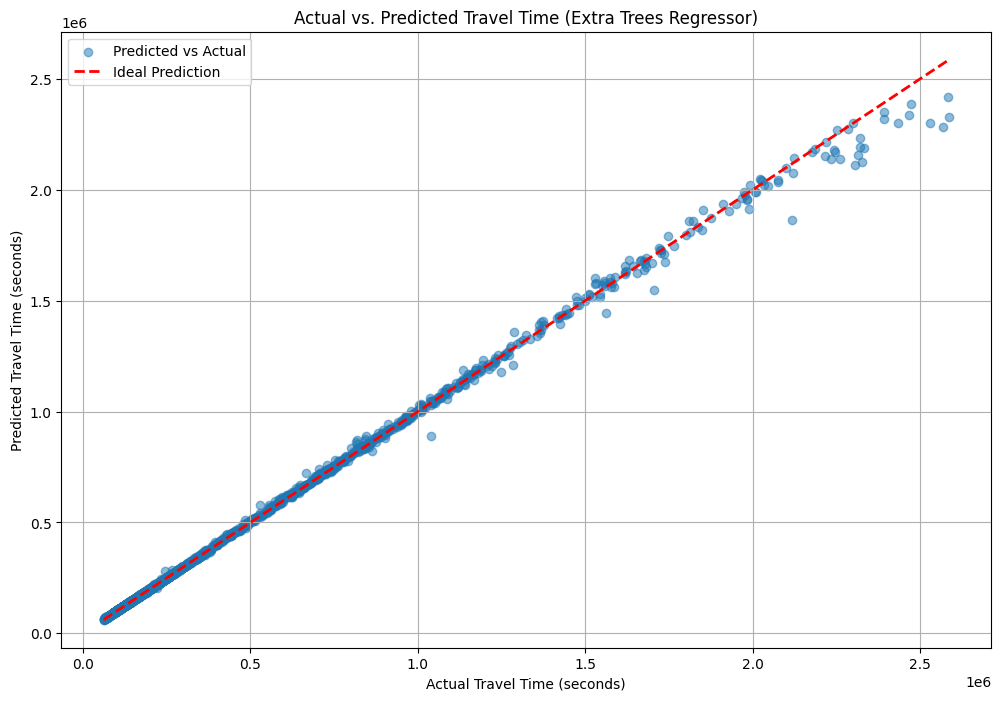

In [13]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))

# Scatter plot with a label
plt.scatter(y_test, et_y_pred, alpha=0.5, label='Predicted vs Actual')

# Red dashed line for perfect predictions with a label
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2, label='Ideal Prediction')

# Add title and labels
plt.title('Actual vs. Predicted Travel Time (Extra Trees Regressor)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)

# Add legend
plt.legend()

# Show the plot
plt.show()

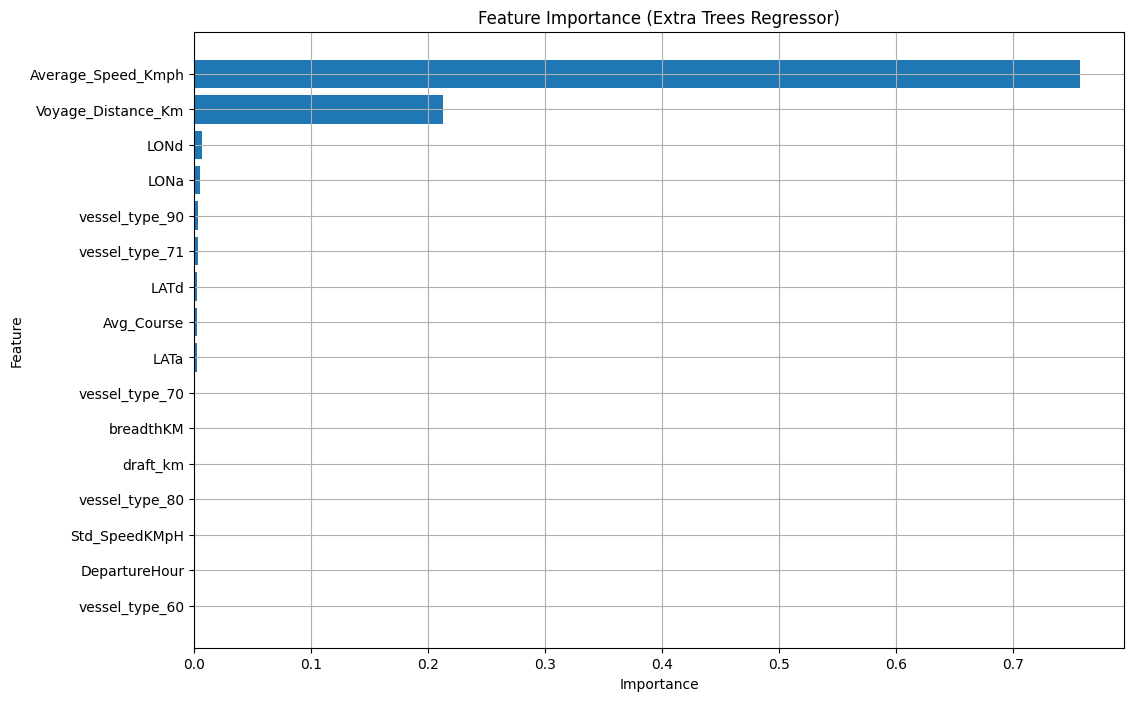

In [11]:
# Feature Importance
feature_importance = best_et_model.feature_importances_
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# Sort features by importance in ascending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plot Feature Importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Extra Trees Regressor)')
plt.grid(True)
plt.show()